# 05 — WARN (Worker Adjustment and Retraining Notification) Dataset

**Goal:** Perform exploratory data analysis (EDA) to uncover patterns in layoffs, specifically:
* How has the number of layoffs change throughout the years in the US? In CA?
* Are more layoffs observed in particular months?
* Which industries are most affected by layoffs?
* Do factors, like company size and region, affect layoffs?

**Time window:** 2020-2025

## Imports

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

## Build dataframe

In [2]:
# load in data
warn_fn = "../data/processed/warn_clean_rows.csv"
warn_df = pd.read_csv(warn_fn)
monthly_fn = "../data/processed/warn_monthly.csv"
monthly_df = pd.read_csv(monthly_fn)

# quick look
warn_df.head(10)

,notice_date,effective_date,received_date,company,city,county,employees_type,col7,source_file,address,employees,layoff_closure_type,layoff_closure_type_raw
0,06/09/2020,06/07/2020,07/01/2020,Bay Club Santa Monica,Santa Monica,Los Angeles County,82 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,82.0,Layoff Permanent,NaN
1,06/19/2020,08/21/2020,07/01/2020,"Weber Metals, Inc",Paramount,Los Angeles County,169 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,169.0,Layoff Permanent,NaN
2,06/09/2020,06/07/2020,07/01/2020,Bay Club Rolling Hills,Rolling Hills Estates,Los Angeles County,64 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,64.0,Layoff Permanent,NaN
3,06/09/2020,06/07/2020,07/01/2020,Bay Club Redondo Beach,Redondo Beach,Los Angeles County,102 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,102.0,Layoff Permanent,NaN
4,06/09/2020,06/07/2020,07/01/2020,Bay Club Ross Valley,Kentfield,Marin County,51 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,51.0,Layoff Permanent,NaN
5,06/09/2020,06/07/2020,07/01/2020,StoneTree Golf Club,Novato,Marin County,32 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,32.0,Layoff Permanent,NaN
6,06/23/2020,06/23/2020,07/01/2020,The Freeman Company LLC,Anaheim,Orange County,29 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,29.0,Layoff Permanent,NaN
7,06/18/2020,03/20/2020,07/01/2020,Hyatt Regency Sacramento,Sacramento,Sacramento County,203 Layoff Permanent,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,203.0,Layoff Permanent,NaN
8,06/18/2020,06/17/2020,07/01/2020,"Granite Summit, Inc",Running Springs,San Bernardino County,60 Layoff Type Unknown,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,60.0,Layoff Type Unknown,NaN
9,06/18/2020,06/17/2020,07/01/2020,Pali Camp,Running Springs,San Bernardino County,71 Layoff Type Unknown,warn7-1-20to6-3-21_table0.csv,warn7-1-20to6-3-21_table0.csv,NaN,71.0,Layoff Type Unknown,NaN


In [3]:
#remove unnecessary columns
warn_df = warn_df.drop(columns=['address', 'city', 'col7', 'source_file', 'layoff_closure_type_raw', 'employees_type'])

In [4]:
warn_df.sample(5)

,notice_date,effective_date,received_date,company,county,employees,layoff_closure_type
1951,01/11/2021,03/12/2021,01/12/2021,Northrop Grumman Corporation,San Diego County,100.0,Layoff Permanent
5591,06/19/2024,08/18/2024,06/19/2024,WestRock,Riverside County,77.0,Closure Permanent
3585,04/24/2023,06/23/2023,05/08/2023,"Meta Platforms, Inc.",San Mateo County,25.0,Layoff Permanent
4939,02/15/2024,04/19/2024,02/20/2024,Excalibur Pizza LLC,Sacramento County,4.0,Layoff Permanent
1015,03/31/2020,03/31/2020,09/19/2020,ASM Global,San Joaquin County,483.0,Layoff Temporary


## Preprocessing

### 1. Summarize the dataset

In [5]:
# display df structure
warn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7142 entries, 0 to 7141
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   notice_date          7142 non-null   object 
 1   effective_date       7141 non-null   object 
 2   received_date        7142 non-null   object 
 3   company              7142 non-null   object 
 4   county               7142 non-null   object 
 5   employees            7049 non-null   float64
 6   layoff_closure_type  7059 non-null   object 
dtypes: float64(1), object(6)
memory usage: 390.7+ KB


In [6]:
# display summary stats
warn_df.describe(include='all')

,notice_date,effective_date,received_date,company,county,employees,layoff_closure_type
count,7142,7141,7142,7142,7142,7049.000000,7059
unique,1252,1397,1058,4012,190,NaN,210
top,11/14/2024,03/31/2023,11/15/2024,"Advance Stores Company, Incorporated and its s...",Los Angeles County,NaN,Layoff Permanent
freq,131,69,134,123,1629,NaN,3948
mean,NaN,NaN,NaN,NaN,NaN,193.403320,NaN
std,NaN,NaN,NaN,NaN,NaN,1316.182508,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,8.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,37.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,87.000000,NaN


### 2. Identify and handle missing, duplicate, or inconsistent data

In [7]:
# check for missing values
warn_df.isnull().sum()

notice_date             0
effective_date          1
received_date           0
company                 0
county                  0
employees              93
layoff_closure_type    83
dtype: int64

Majority of missing values were observed in `employees` and `layoff_closure_type`, and since the data is large, we can remove these specific rows to avoid impact in our analyses.

In [8]:
# removing rows with null values
warn_df = warn_df.dropna()

7038 rows of cleaned preprocessed data are still available to conduct analysis.

In [9]:
warn_df['layoff_closure_type'].unique()

array(['Layoff Permanent', 'Layoff Type Unknown', 'Layoff Temporary',
       ',529 Layoff Temporary', 'Closure Permanent', 'Closure Temporary',
       ',139 Layoff Temporary', ',047 Layoff Permanent',
       'Closure Type Unknown', ',284 Layoff Permanent',
       ',890 Layoff Temporary', ',356 Layoff Type Unknown',
       ',681 Layoff Permanent', ',207 Layoff Permanent',
       ',260 Layoff Temporary', ',136 Closure Temporary',
       ',750 Layoff Temporary', ',912 Layoff Temporary',
       ',185 Layoff Permanent', ',690 Layoff Temporary',
       ',500 Closure Temporary', 'Layoff Not known at this time',
       'Layoff Not known at', ',755 Closure Permanent',
       ',015 Layoff Temporary', ',064 Layoff Permanent',
       'Hawthorne Street  San Francisco CA 94105',
       'W. Maude Avenue  Sunnyvale CA 94085',
       'E. Middlefield Road  Mountain View CA 94043',
       'Second Street  San Francisco CA 94105',
       'Market St  San Francisco CA 94105',
       'Montgomery St  San Franc

In [10]:
# encoding layoff_closure_permanent (1 = permanent, 0 = temporary)
warn_df['layoff_closure_type'] = warn_df['layoff_closure_type'].str.lower().str.strip()
warn_df['layoff_closure_type'] = warn_df['layoff_closure_type'].apply(
    lambda x: 1 if 'permanent' in x else 0
)

In [11]:
# checking unique values of county
warn_df['county'].unique()

array(['Los Angeles County', 'Marin County', 'Orange County',
       'Sacramento County', 'San Bernardino County',
       'San Francisco County', 'San Mateo County', 'Santa Clara County',
       'Ventura County', 'Kern County', 'Stanislaus County',
       'Contra Costa County', 'Alameda County', 'San Diego County',
       'San Joaquin County', 'Yolo County', 'Placer County',
       'Riverside County', 'San Luis Obispo County', 'Napa County',
       'Santa Barbara County', 'Shasta County', 'Sonoma County',
       'Solano County', 'Calaveras County', 'Plumas County',
       'Fresno County', 'Merced County', 'Sutter County', 'Butte County',
       'Tulare County', 'Santa Cruz County', 'Yuba County',
       'Monterey County', 'Madera County', 'Imperial County',
       'Kings County', 'El Dorado County', 'Mendocino County',
       'Siskiyou County', 'Tehama County', 'Mono County', 'Glenn County',
       'Del Norte County', 'Inyo County', 'Mariposa County',
       'Tuolumne County', 'San Ben

We see that there is some dirty entries in this column. This is most likely from the conversion of pdf to csv. Let's clean this.

In [12]:
warn_df = warn_df[~warn_df['county'].str.contains(r'\d', na=False)]

In [13]:
warn_df['county'].unique()

array(['Los Angeles County', 'Marin County', 'Orange County',
       'Sacramento County', 'San Bernardino County',
       'San Francisco County', 'San Mateo County', 'Santa Clara County',
       'Ventura County', 'Kern County', 'Stanislaus County',
       'Contra Costa County', 'Alameda County', 'San Diego County',
       'San Joaquin County', 'Yolo County', 'Placer County',
       'Riverside County', 'San Luis Obispo County', 'Napa County',
       'Santa Barbara County', 'Shasta County', 'Sonoma County',
       'Solano County', 'Calaveras County', 'Plumas County',
       'Fresno County', 'Merced County', 'Sutter County', 'Butte County',
       'Tulare County', 'Santa Cruz County', 'Yuba County',
       'Monterey County', 'Madera County', 'Imperial County',
       'Kings County', 'El Dorado County', 'Mendocino County',
       'Siskiyou County', 'Tehama County', 'Mono County', 'Glenn County',
       'Del Norte County', 'Inyo County', 'Mariposa County',
       'Tuolumne County', 'San Ben

In [14]:
# check for duplicate data
warn_df.duplicated().sum()

10

In [15]:
# drop duplicates
warn_df = warn_df.drop_duplicates()

In [17]:
# check count of our data (how many entries do we have after preprocessing?)
warn_df.shape

(6848, 7)

### 3. Calculate measures like mean, median, standard deviation, and correlations

In [18]:
warn_df[['employees']].describe()

,employees
count,6848.000000
mean,73.608353
std,247.975890
min,1.000000
25%,8.000000
50%,35.000000
75%,82.000000
max,16132.000000


In [19]:
warn_df.groupby('layoff_closure_type')['employees'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
layoff_closure_type,,,,
0,1051,124.586108,62.0,301.905635
1,5797,64.366051,30.0,235.740761


Temporary layoffs seem to be much larger (12x more) on average than permanent ones. Which is actually the opposite of what we assumed. Temporary layoffs have massive outliers, where the standard deviation is exptremely large. Let's find out why.

In [20]:
# converting notice_date to datetime value
warn_df['notice_date'] = pd.to_datetime(warn_df['notice_date'])

In [21]:
#creating new columns for each datetime value
warn_df['year'] = warn_df['notice_date'].dt.year
warn_df['month'] = warn_df['notice_date'].dt.month
warn_df['year_month'] = warn_df['notice_date'].dt.to_period('M')

In [22]:
# finding number of temporary layoffs per year
temp_layoffs_per_year = (
    warn_df[warn_df['layoff_closure_type'] == 0]
    .groupby('year')
    .size()
)
temp_layoffs_per_year

year
2020    835
2021     81
2022     39
2023     38
2024     44
2025     14
dtype: int64

As we notice, there were significantly more temporary layoffs in the year 2020 compared to the rest of the years (2021 - 2025). This pattern is very consistent with the **COVID-19** impact, where businesses shut down suddently and many went through temprary closings. Companies expected reopenings, so layoffs were classified as temporary. This number makes a lot of sense.

In [23]:
perm_layoffs_per_year = (
    warn_df[warn_df['layoff_closure_type'] == 1]
    .groupby('year')
    .size()
)
perm_layoffs_per_year

year
2019       1
2020     917
2021     527
2022     796
2023    1509
2024    1384
2025     663
dtype: int64

Permanent layoffs stayed decently consistent throughout the time frame of our dataset, but temporary layoffs collapse sharply and permanent layoffs become more common relative to temporary.

### 4. Visualizations (e.g., histograms, scatter plots, heatmaps)

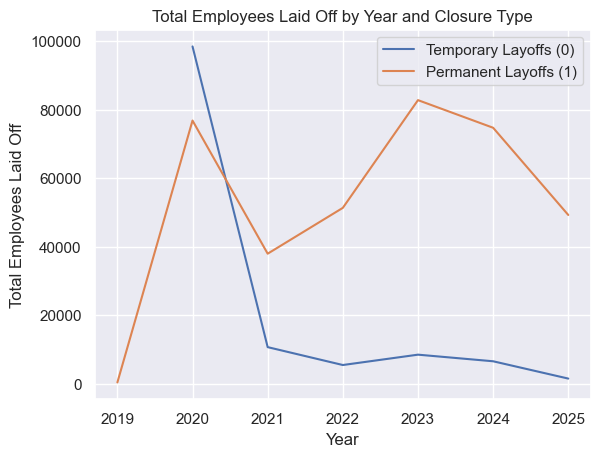

In [37]:
yearly = warn_df.groupby(['year','layoff_closure_type'])['employees'].sum().unstack()

plt.figure()
plt.plot(yearly.index, yearly[0], label="Temporary Layoffs (0)")
plt.plot(yearly.index, yearly[1], label="Permanent Layoffs (1)")
plt.xlabel("Year")
plt.ylabel("Total Employees Laid Off")
plt.title("Total Employees Laid Off by Year and Closure Type")
plt.legend()
plt.show()

This figure shows the total number of employees affected by company layoffs at each year, and separated by temporary and permanent layoff types. Temporary layoffs seems to spike in 2020, which directly correlates to the operational shutdowns during the COVID-19 pandemic. After 2020, temporary layoffs decline sharply and remain relatively low. On the other hand, permanent layoffs remain to be somewhat constant (maintaining itself within a range of 20,000), and peaking around 2023.

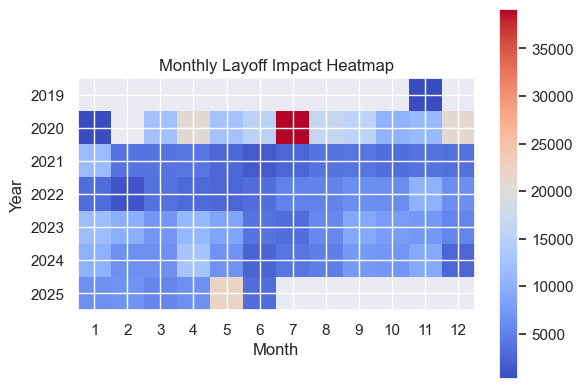

In [41]:
monthly = warn_df.groupby(['year','month'])['employees'].sum().unstack()

plt.figure()
plt.imshow(monthly.values, cmap='coolwarm')
plt.xticks(range(12), monthly.columns)
plt.yticks(range(len(monthly.index)), monthly.index)
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Monthly Layoff Impact Heatmap")
plt.colorbar()
plt.show()

The heatmap shows a sharp spike in layoffs during 2020, concentrated the early and mid year months, reflecting the immediate impact of COVID-19, where companies ridded of staff all of a sudden. Layoffs decline during the years of 2021-2022 and rises again in 2023-2024 but in a more distributed pattern, suggesting more longer-term economic structuring rather than a single event causing it.

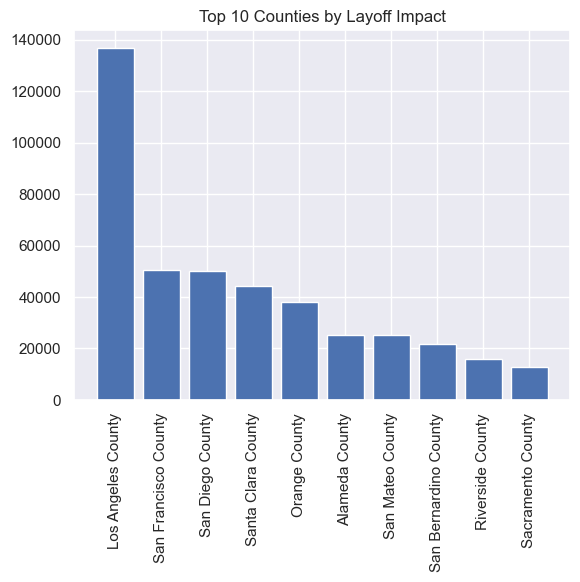

In [34]:
top_counties = warn_df.groupby('county')['employees'].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_counties.index, top_counties.values)
plt.xticks(rotation=90)
plt.title("Top 10 Counties by Layoff Impact")
plt.show()

According to this dataset, LA county accounts for the largest layoff impact by a substantial margin. Major urban and tech-centered counties such as SF, SD, and Santa Clara also show high layoff volumes. We can conclude from this that workforce reductions are heavily concentrated in a few key economic hubs rather than evenly distributed across regions.

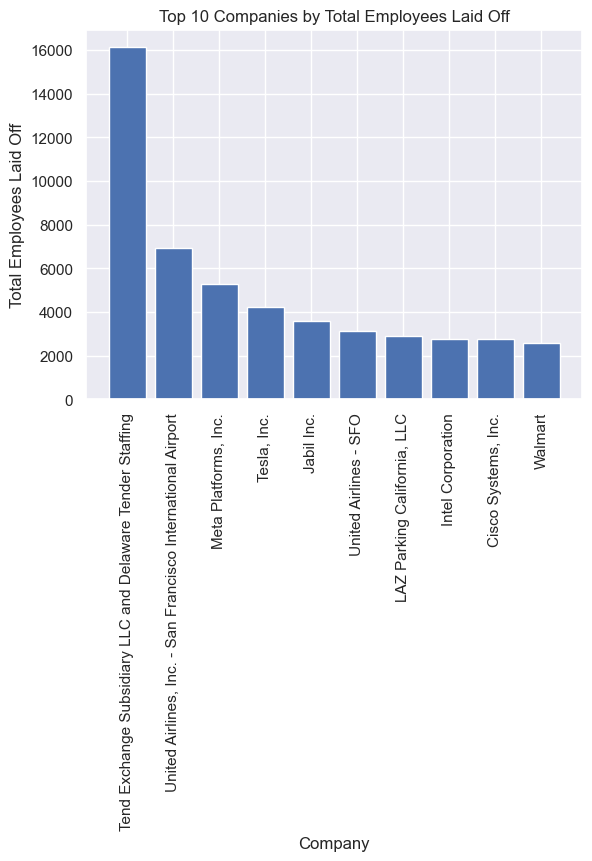

In [44]:
# top 10 companies by total employees laid off
company_totals = (
    warn_df.groupby('company')['employees']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.bar(company_totals.index, company_totals.values)
plt.xticks(rotation=90)
plt.xlabel("Company")
plt.ylabel("Total Employees Laid Off")
plt.title("Top 10 Companies by Total Employees Laid Off")
plt.show()

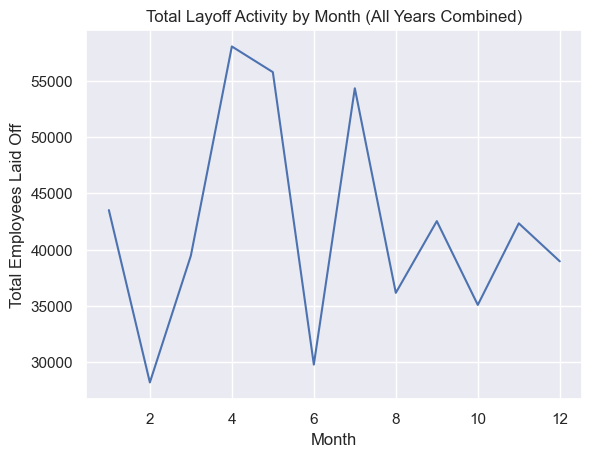

In [43]:
# layoff activity by month
monthly_totals = (
    warn_df.groupby('month')['employees']
    .sum()
    .sort_index()
)

plt.figure()
plt.plot(monthly_totals.index, monthly_totals.values)
plt.xlabel("Month")
plt.ylabel("Total Employees Laid Off")
plt.title("Total Layoff Activity by Month (All Years Combined)")
plt.show()

### 5. Hypotheses formation to guide future analysis

1. Temporary layoffs were significantly larger in size during 2020 compared to other years, reflecting the acute economic shock caused by the COVID-19 pandemic.

2. Layoff impact is highly concentrated among a small number of companies and counties, with a few large employers and major economic hubs accounting for a larger share of total employees affected.

3. Layoff activity is driven more by macroeconomic events than by seasonality, as evidenced by the sharp 2020 spike and lack of consistent monthly patterns across other years.